In [35]:
# %pip install yt_dlp
# %pip install -q dvt

In [2]:
import os
import av
import cv2
import numpy as np
import pandas as pd
import os
from yt_dlp import YoutubeDL
from dvt_mod.annotate_mod import yield_video
from dvt_mod.annotate_mod import annotate_shots
import matplotlib.pyplot as plt
import dvt
import polars as pl
from PIL import Image
import io


TEMP_DIR = './temp_video'

def download_video(url):
    """1. Downloads the video and returns the actual file path."""
    if not os.path.exists(TEMP_DIR):
        os.makedirs(TEMP_DIR)
        
    ydl_opts = {
        'outtmpl': os.path.join(TEMP_DIR, 'input.%(ext)s'),
        'format': 'bestvideo[height<=720][ext=mp4]/best[ext=mp4]',
        'quiet': True,
        'no_warnings': True,
        'cookiefile': 'youtube-cookies.txt'
    }

    with YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        return ydl.prepare_filename(info)


def cleanup(file_path):
    """4. Deletes the file if it exists."""
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Cleanup: Deleted {file_path}")




In [3]:
target_url = 'https://www.youtube.com/watch?v=Unfpbdbo3hY'
vid_filename = download_video(target_url)
vid_filename


'./temp_video/input.mp4'

In [38]:


meta = dvt.video_info(vid_filename)
meta

{'frame_count': 1633.0, 'height': 720.0, 'width': 1280.0, 'fps': 23.961}

In [39]:
from dvt_mod.annotate_mod import annotate_shots

output = annotate_shots(vid_filename)

/home/kescher/kyrgyz-youtube-visual-audit/models/dvt_detect_shots.pt
Processing video frames 750/1633

KeyboardInterrupt: 

In [ ]:
dt = pl.from_dict(output['scenes'])
dt = dt.with_columns((pl.col("start") / meta['fps']).alias("start_time"))
dt = dt.with_columns((pl.col("end") / meta['fps']).alias("end_time"))
dt

start,end,start_time,end_time
i32,i32,f64,f64
0,46,0.0,1.919786
47,64,1.961521,2.671007
65,113,2.712742,4.715997
114,147,4.757731,6.134969
148,231,6.176704,9.640666
…,…,…,…
340,359,14.189725,14.98268
360,433,15.024415,18.071032
434,1385,18.112767,57.802262


In [ ]:
from dvt_mod.annotate_mod import yield_video

first_frames = []
for image, frame, timestamp in yield_video(vid_filename):
    if frame in dt['start'].to_list():
        first_frames += [frame]
        pimg = Image.fromarray(image, 'RGB')
        display(pimg)

In [ ]:
# https://distantviewing.org/dvscripts/tutorial-digital-images.html

hue_text = """cnom,start,end,mid
red,0.000000,0.015625,0.007812
orange,0.015625,0.109375,0.062500
yellow,0.109375,0.203125,0.156250
green,0.203125,0.453125,0.328125
cyan,0.453125,0.546875,0.500000
blue,0.546875,0.765625,0.656250
violet,0.765625,0.953125,0.859375
red,0.953125,1.000000,0.976562"""

# Use io.StringIO to treat the string as a file
hue = pd.read_csv(io.StringIO(hue_text))

print(hue)

     cnom     start       end       mid
0     red  0.000000  0.015625  0.007812
1  orange  0.015625  0.109375  0.062500
2  yellow  0.109375  0.203125  0.156250
3   green  0.203125  0.453125  0.328125
4    cyan  0.453125  0.546875  0.500000
5    blue  0.546875  0.765625  0.656250
6  violet  0.765625  0.953125  0.859375
7     red  0.953125  1.000000  0.976562


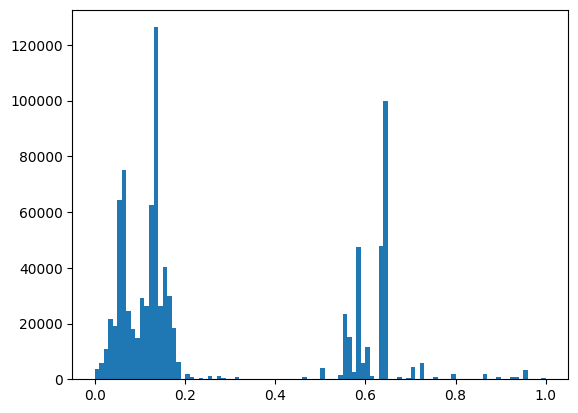

[    0 73604    76     0     0     0     0]


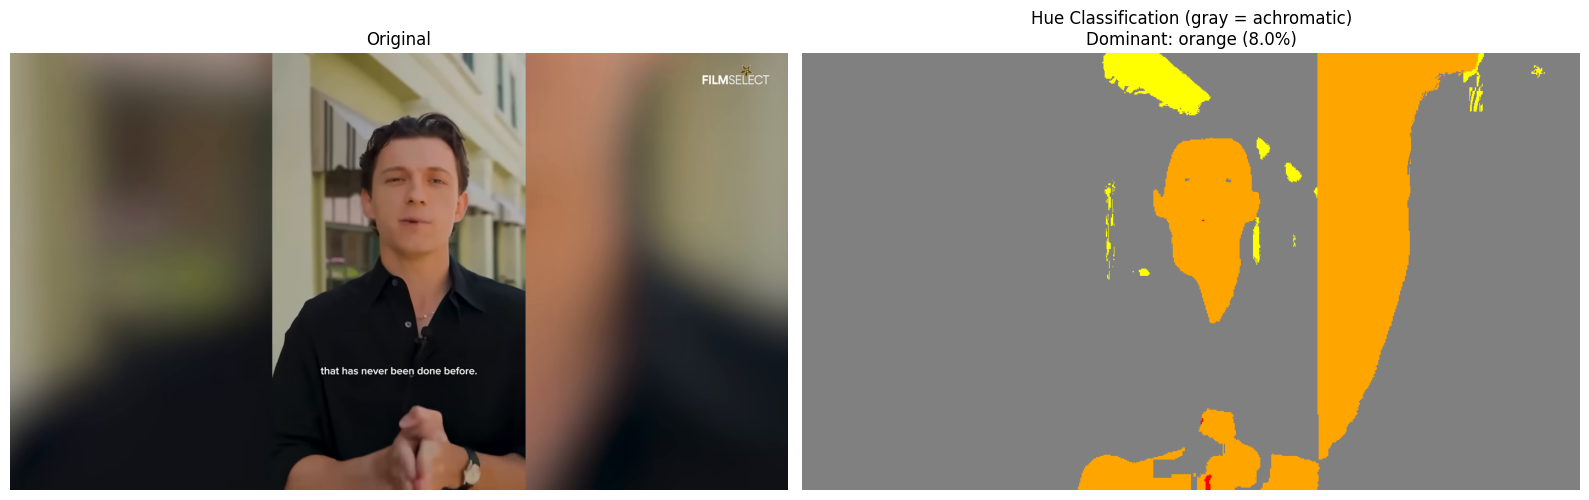

{'avg_brightness': 0.3740368455541938, 'avg_chroma': 0.1146427740799479, 'brightness_std': 0.22852731059866127, 'chroma_std': 0.09632027851821807, 'dom_color': 'orange', 'dom_color_percent': np.float64(7.986545138888888)}


In [ ]:
# FOR DEBUGGING
# VISUAL INSPECTION CHECK TO MAKE SURE THAT THE FRAME ONE SECOND INTO VIDEO IS CORRECTLY COLOR LABELED

for image, frame, timestamp in yield_video(vid_filename):
    if frame == 930:
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float64)

        hsv[:, :, 0] = hsv[:, :, 0] / 179.0
        hsv[:, :, 1] = hsv[:, :, 1] / 255.0
        hsv[:, :, 2] = hsv[:, :, 2] / 255.0

        h = hsv[:, :, 0] 
        s = hsv[:, :, 1]
        v = hsv[:, :, 2] 

        chroma_2d = s * v
        chromatic_mask = chroma_2d > 0.2
        display_colors = {
            "red":    [255, 0, 0],
            "orange": [255, 165, 0],
            "yellow": [255, 255, 0],
            "green":  [0, 180, 0],
            "cyan":   [0, 255, 255],
            "blue":   [0, 0, 255],
            "violet": [128, 0, 128],
        }
        ACHROMATIC_COLOR = [128, 128, 128]  
        classified = np.full((*h.shape, 3), ACHROMATIC_COLOR, dtype=np.uint8)
        for _, row in hue.iterrows():
            hue_mask = (h >= row["start"]) & (h < row["end"]) & chromatic_mask
            color_name = row["cnom"]
            # both "red" rows map to the same display color
            if color_name in display_colors:
                classified[hue_mask] = display_colors[color_name]

        hsv = hsv.reshape((-1, 3))

        plt.hist(hsv[hsv[:,1] * hsv[:,2] > 0, 0], bins=100)
        plt.show()

        chroma = s * v
        
        flat = np.stack([h.ravel(), s.ravel(), v.ravel()], axis=1)
        chromatic = flat[flat[:, 1] * flat[:, 2] > 0.3]

        if len(chromatic) > 0:
            bins = np.append(0, hue.end.values)
            cnt, _ = np.histogram(hsv[(hsv[:,1] * hsv[:,2] > 0.3), 0], bins = bins)
            cnt[0] = cnt[0] + cnt[7]
            cnt = cnt[:7]

            print(cnt)

            dom_color = hue.cnom.values[np.argmax(cnt)]
            color_percent = np.max(cnt) / hsv.shape[0] * 100
        else:
            dom_color = "achromatic"
            dom_color_percent = 0.0

        features = {
            "avg_brightness": float(np.mean(v)),
            "avg_chroma":     float(np.mean(chroma)),
            "brightness_std": float(np.std(v)),
            "chroma_std":     float(np.std(chroma)),
            "dom_color" :     dom_color,
            "dom_color_percent":    color_percent
        }

        import matplotlib.patches as mpatches

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        axes[0].imshow(image)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(classified)
        axes[1].set_title(f"Hue Classification (gray = achromatic)\nDominant: {dom_color} ({color_percent:.1f}%)")
        axes[1].axis("off")

        legend_patches = [
            mpatches.Patch(color=np.array(c)/255, label=name)
            for name, c in display_colors.items()
        ]
        legend_patches.append(
            mpatches.Patch(color=np.array(ACHROMATIC_COLOR)/255, label="achromatic")
        )
        # axes[1].legend(handles=legend_patches, loc="lower right", fontsize=9)

        plt.tight_layout()
        plt.show()

        print(features)
        break


In [ ]:

frame_info = {}

for image, frame, timestamp in yield_video(vid_filename):
    if frame % 30 == 0:
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float64)

        hsv[:, :, 0] = hsv[:, :, 0] / 179.0
        hsv[:, :, 1] = hsv[:, :, 1] / 255.0
        hsv[:, :, 2] = hsv[:, :, 2] / 255.0

        h = hsv[:, :, 0] 
        s = hsv[:, :, 1]
        v = hsv[:, :, 2] 

        hsv = hsv.reshape((-1, 3))
        chroma = s * v
        
        flat = np.stack([h.ravel(), s.ravel(), v.ravel()], axis=1)
        chromatic = flat[flat[:, 1] * flat[:, 2] > 0.3]

        if len(chromatic) > 0:
            bins = np.append(0, hue.end.values)
            cnt, _ = np.histogram(hsv[(hsv[:,1] * hsv[:,2] > 0.3), 0], bins = bins)
            cnt[0] = cnt[0] + cnt[7]
            cnt = cnt[:7]
            dom_color = hue.cnom.values[np.argmax(cnt)]
            color_percent = np.max(cnt) / hsv.shape[0] * 100
        else:
            dom_color = "achromatic"
            dom_color_percent = 0.0

        features = {
            "avg_brightness": float(np.mean(v)),
            "avg_chroma":     float(np.mean(chroma)),
            "brightness_std": float(np.std(v)),
            "chroma_std":     float(np.std(chroma)),
            "dom_color" :     dom_color,
            "dom_color_percent":    color_percent
        }
        
        frame_info[frame] = features


In [ ]:
frame_info

from collections import Counter

counts = Counter(v["dom_color"] for v in frame_info.values())
print(counts)

Counter({'orange': 37, 'yellow': 12, 'red': 6})


In [ ]:
# # compiled into our final pipeline

# video_path = vid_filename

# vid_info = {}

# meta = dvt.video_info(video_path)
# vid_info['meta'] = meta
    
# # get scene breaks
# output = annotate_shots(video_path)
# dt = pl.from_dict(output['scenes'])
# dt = dt.with_columns((pl.col("start") / meta['fps']).alias("start_time"))
# dt = dt.with_columns((pl.col("end") / meta['fps']).alias("end_time"))

# vid_info['scenes'] = dt.to_dicts()

# # get color info across frames
# hue_text = """cnom,start,end,mid
# red,0.000000,0.015625,0.007812
# orange,0.015625,0.109375,0.062500
# yellow,0.109375,0.203125,0.156250
# green,0.203125,0.453125,0.328125
# cyan,0.453125,0.546875,0.500000
# blue,0.546875,0.765625,0.656250
# violet,0.765625,0.953125,0.859375
# red,0.953125,1.000000,0.976562"""

# # Use io.StringIO to treat the string as a file
# hue = pd.read_csv(io.StringIO(hue_text))

# frame_info = {}

# for image, frame, timestamp in yield_video(video_path):
#     if frame % 30 == 0:
#         hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float64)

#         hsv[:, :, 0] = hsv[:, :, 0] / 179.0
#         hsv[:, :, 1] = hsv[:, :, 1] / 255.0
#         hsv[:, :, 2] = hsv[:, :, 2] / 255.0

#         h = hsv[:, :, 0] 
#         s = hsv[:, :, 1]
#         v = hsv[:, :, 2] 

#         hsv = hsv.reshape((-1, 3))
#         chroma = s * v
        
#         flat = np.stack([h.ravel(), s.ravel(), v.ravel()], axis=1)
#         chromatic = flat[flat[:, 1] * flat[:, 2] > 0.3]

#         if len(chromatic) > 0:
#             bins = np.append(0, hue.end.values)
#             cnt, _ = np.histogram(hsv[(hsv[:,1] * hsv[:,2] > 0.3), 0], bins = bins)
#             cnt[0] = cnt[0] + cnt[7]
#             cnt = cnt[:7]
#             dom_color = hue.cnom.values[np.argmax(cnt)]
#             color_percent = np.max(cnt) / hsv.shape[0] * 100
#         else:
#             dom_color = "achromatic"
#             dom_color_percent = 0.0

#         features = {
#             "avg_brightness": float(np.mean(v)),
#             "avg_chroma":     float(np.mean(chroma)),
#             "brightness_std": float(np.std(v)),
#             "chroma_std":     float(np.std(chroma)),
#             "dom_color" :     dom_color,
#             "dom_color_percent":    color_percent
#         }
        
#         frame_info[frame] = features

# vid_info['frames'] = frame_info

/home/kescher/kyrgyz-youtube-visual-audit/models/dvt_detect_shots.pt
Processing video frames 1633/1633


In [ ]:
cleanup(vid_filename)

In [ ]:
all_urls_df = pd.read_csv("../data/raw/all_urls_labels.csv")
urls_df = pd.read_csv("../data/raw/all_urls_labels.csv")
urls_df = urls_df[urls_df['most_recommended_demographic'] == 'child']
urls_df = urls_df[((urls_df['is_russian'] == 't') | (urls_df['is_kyrgyz_x'] == 't')) | (urls_df['is_english'] == 't')]


In [44]:
urls_df[((urls_df['is_russian'] == 't') | (urls_df['is_kyrgyz_x'] == 't')) | (urls_df['is_english'] == 't')]

,url,is_russian,is_kyrgyz_x,is_english,is_unknown,is_unreachable_x,is_no_language,other_lang,is_slavic,is_kyrgyz_y,is_other_central_asian,is_caucasian,is_other,is_no_people,is_unreachable_y,most_recommended_demographic
1,https://www.youtube.com/watch?v=uXAtWZ7RNAc,f,f,t,f,f,f,NaN,f,f,f,f,f,t,f,child
2,https://www.youtube.com/watch?v=JVtJbWeIU68,f,f,t,f,f,f,NaN,f,f,f,f,t,f,f,child
5,https://www.youtube.com/watch?v=QXglaxD5fag,t,f,f,f,f,f,NaN,f,f,f,f,f,t,f,child
14,https://www.youtube.com/watch?v=RJJ3j1dfD8s,t,f,f,f,f,f,NaN,t,f,f,f,f,f,f,child
27,https://www.youtube.com/watch?v=dDwL_P9A5D4,t,f,f,f,f,f,NaN,f,f,f,f,f,t,f,child
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10676,https://www.youtube.com/watch?v=L0G7jK56uO4,t,f,t,f,f,f,NaN,f,f,f,f,f,t,f,child
10686,https://www.youtube.com/watch?v=eg084ijKeFw,t,f,f,f,f,f,NaN,f,f,f,f,f,t,f,child
10697,https://www.youtube.com/watch?v=t0Q2otsqC4I,f,f,t,f,f,f,NaN,f,f,f,f,f,t,f,child
10704,https://www.youtube.com/watch?v=Icg1qYs40Po,t,f,f,f,f,f,NaN,f,f,f,f,f,t,f,child


In [ ]:
urls = urls_df["url"].tolist()